# Case - Fuel Consumption

- In vehicle efficiency studies, a car's performance is often judged based on its ability to save energy under various road conditions. In this case, we analyze the relationship between `Hwy` (fuel consumption on the highway, in L/100 km) and `Fuel_Consumption` (combined fuel consumption, in L/100 km) — two key measures of a vehicle's operational efficiency.

- A lower `Hwy` value indicates better fuel economy on the highway, meaning the vehicle consumes fewer litres per 100 km under highway driving conditions, which generally reflects a vehicle's aerodynamic qualities and transmission efficiency.

- The purpose of this analysis is to compare three regression modeling approaches to find the most accurate model in capturing the correlation between highway fuel consumption (`Hwy`) and total combined fuel consumption (`Fuel_Consumption`).


In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
import statsmodels.formula.api as smf

In [2]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from statsmodel library
    :return df: <pandas DataFrame>
    """
    coef = results.params
    std_err = results.bse

    df = pd.DataFrame(data = np.transpose([coef, std_err]),
                      index = coef.index,
                      columns=["coef","std err"])
    return df

### Load Data

In [3]:
car = pd.read_csv('Fuel_Consumption.csv', encoding='ISO-8859-1')
car.head()

,Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel Type,Fuel_Consumption,Hwy,Comb,MPG,Emissions,CO2_Rating,Smog_Rating
0,2023,Acura,Integra,Full-size,1.5,4.0,AV7,Z,7.9,6.3,7.2,39.0,167.0,6.0,7.0
1,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,AV7,Z,8.1,6.5,7.4,38.0,172.0,6.0,7.0
2,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,M6,Z,8.9,6.5,7.8,36.0,181.0,6.0,6.0
3,2023,Acura,MDX SH-AWD,SUV: Small,3.5,6.0,AS10,Z,12.6,9.4,11.2,25.0,263.0,4.0,5.0
4,2023,Acura,MDX SH-AWD Type S,SUV: Standard,3.0,6.0,AS10,Z,13.8,11.2,12.4,23.0,291.0,4.0,5.0


In [4]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              841 non-null    object 
 1   Make              853 non-null    object 
 2   Model             833 non-null    object 
 3   Vehicle_Class     833 non-null    object 
 4   Engine_Size       833 non-null    float64
 5   Cylinders         833 non-null    float64
 6   Transmission      833 non-null    object 
 7   Fuel Type         833 non-null    object 
 8   Fuel_Consumption  833 non-null    float64
 9   Hwy               833 non-null    float64
 10  Comb              833 non-null    float64
 11  MPG               833 non-null    float64
 12  Emissions         833 non-null    float64
 13  CO2_Rating        833 non-null    float64
 14  Smog_Rating       833 non-null    float64
dtypes: float64(9), object(6)
memory usage: 100.4+ KB


- Check the pattern in *`Hwy`* and *`Fuel_Consumption`* using visualization

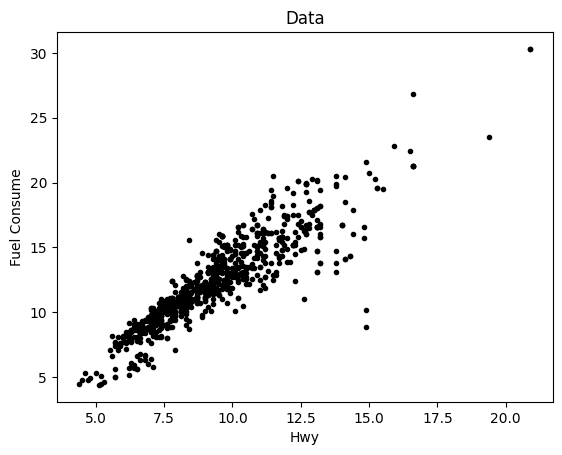

In [5]:
x = car['Hwy']
y = car['Fuel_Consumption']

# Plot the data
plt.scatter(x, y, color = "k", marker=".")

# Add a legend and labels

plt.xlabel("Hwy")
plt.ylabel("Fuel Consume")

# Add a title and adjust the margins
plt.title("Data")

# Show the plot
plt.show()

- The scatterplot shows a very strong positive relationship between highway fuel consumption (`Hwy`) and combined fuel consumption (`Fuel_Consumption`). Vehicles with higher highway fuel consumption consistently tend to have higher combined fuel consumption as well.

- The graph shows that the relationship between these two fuel consumption measures forms a very clear linear pattern; the data points are distributed along an upward diagonal line, indicating that as highway consumption increases, combined consumption increases proportionally.

- Let's try fitting a linear regression model first to see how well a straight-line relationship captures this pattern, before exploring non-linear transformations.


### Fit Linear Regression - Using `HWY` Variable

- Build the model using ols

In [6]:
# Create OLS model object
model = smf.ols("Fuel_Consumption ~ Hwy", car)

# Fit the model
results_model_car = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_fuel = print_coef_std_err(results_model_car)

### Insight

In [7]:
results_fuel

,coef,std err
Intercept,-0.138488,0.219043
Hwy,1.340008,0.022670


$$\text{Fuel Consumption} = -0.138 + 1.340\times\text{Hwy}$$

- For every 1 L/100 km increase in highway fuel consumption (`Hwy`), the combined fuel consumption (`Fuel_Consumption`) is predicted to increase by an average of **1.34 L/100 km**.


In [8]:
expected_score_10 = results_fuel['coef']['Intercept']+results_fuel['coef']['Hwy']*5
expected_score_10

np.float64(6.561551993464285)

In [9]:
expected_score_15 = results_fuel['coef']['Intercept']+results_fuel['coef']['Hwy']*7
expected_score_15

np.float64(9.241567993378926)

In [10]:
diff_score_10 = expected_score_15-expected_score_10
diff_score_10

np.float64(2.680015999914641)

- Regression estimates show that a vehicle with 2 L/100 km higher highway fuel consumption (`Hwy`) is predicted to have a combined fuel consumption that is **2.68 L/100 km** higher on average.

- These results can be further used to calculate technical or financial simulations — for example, to evaluate whether improvements in highway driving efficiency are sufficient to meet targeted combined fuel consumption standards.


### Limitation :

- This model assumes a rigid linear relationship, where every 2 L/100 km increase in highway fuel consumption (`Hwy`) will always result in a 2.68 L/100 km increase in combined fuel consumption, without considering differences in engine efficiency thresholds across vehicle types.

- The estimates are deterministic based on the coefficient $1.340$, so predictions may not be accurate when applied to real-world driving conditions outside the range of `Hwy` values observed in this dataset.

- The difference score calculation generalizes across the entire sample, even though the relationship between highway and combined fuel consumption can vary significantly depending on vehicle-specific factors such as engine size, transmission type, and vehicle class.


### Evaluation

- Visualize the data and the regression line

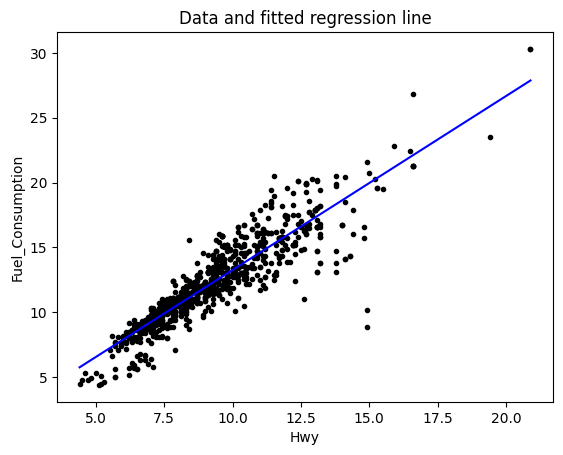

In [11]:
predictor = "Hwy"
outcome = "Fuel_Consumption"
data = car.copy()
results_ = results_fuel.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], color = "k", marker=".")

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc["Hwy"]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)

fitted_values = a_hat + b_hat * x_domain

# Plot the fitted line
plt.plot(x_domain, fitted_values, label="Fitted line", color = "b")

# Add a legend and labels
# plt.legend()
plt.ylabel(outcome)
plt.xlabel(predictor)

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

- The regression line sits above the majority of data points on the left side — vehicles with low highway fuel consumption (`Hwy`) that tend to be more fuel-efficient overall. It passes through the middle of the cluster in the central area, and falls slightly below some data points on the right side where both `Hwy` and `Fuel_Consumption` values are very high.


### Residual Plot and Explained Variance

Text(0.5, 1.0, 'Residuals vs. Predicted Fuel Consumption')

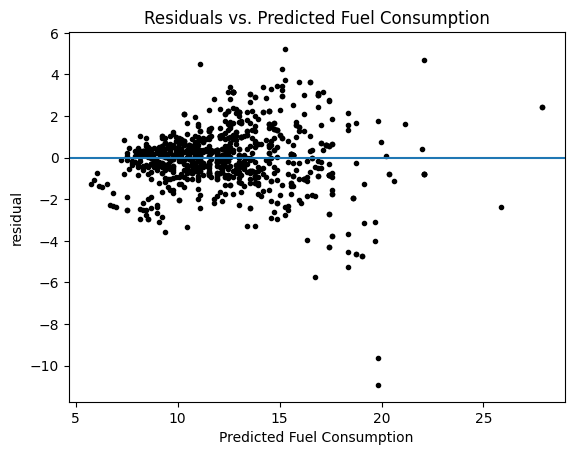

In [12]:
plt.scatter(results_model_car.fittedvalues, results_model_car.resid, marker=".", c = "k")

# Plot the horizontal line in 0 as the fitted line
plt.axhline([0])

plt.xlabel("Predicted Fuel Consumption")
plt.ylabel("residual")
plt.title(f"Residuals vs. Predicted Fuel Consumption")

In [13]:
r2_linear = results_model_car.rsquared
print(f"R² (Linear Model) = {r2_linear:.6f}  ({r2_linear*100:.4f}% of variance explained)")

R² (Linear Model) = 0.807856  (80.7856% of variance explained)


- The $R^2$ value shows that the linear model is able to explain most of the variation in combined fuel consumption, accounting for **80.79%** of the existing variance ($R^2 \approx 0.8079$).

- This indicates a very strong fit, meaning that highway fuel consumption (`Hwy`) alone is already a highly informative predictor of combined fuel consumption (`Fuel_Consumption`).


### Normality of error assumption

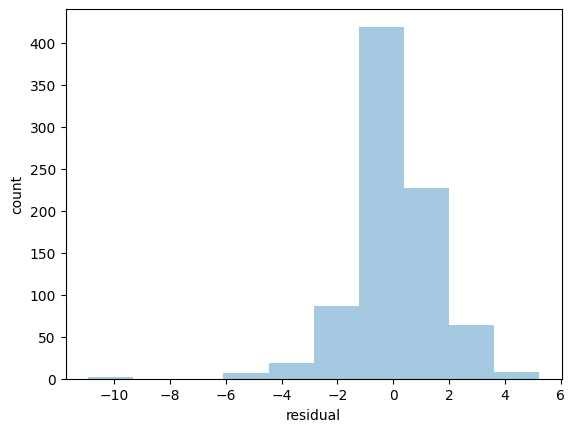

In [14]:
plt.hist(results_model_car.resid, color='tab:blue', alpha=0.4)
plt.xlabel("residual")
plt.ylabel("count")

plt.show()

- The residual distribution in the histogram shows a shape approaching a bell curve, indicating that the normality of residuals assumption is largely met. Most residuals are concentrated around zero, which is a good sign for the reliability of the linear model.

- Model quality can be maintained or further refined without drastic data transformations, unless nonlinear patterns are found in other residual analyses. This is important to ensure that the relationship between highway and combined fuel consumption does not have hidden curvilinear properties.

- Even when the residual distribution appears approximately normal, applying a transformation can still be an option if we want to capture more complex functional patterns or handle the outliers visible in the histogram.

- Non-linear transformations such as reciprocal ($1/x$) or logarithmic ($\log x$) on the `Hwy` variable may be worth exploring to see whether the model fit can be improved beyond the current linear baseline.


### Fit Linear Regression - Using Log Transform on `Hwy` Variable


In [15]:
car['logHwy'] = np.log(car['Hwy'])
car.head()

,Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel Type,Fuel_Consumption,Hwy,Comb,MPG,Emissions,CO2_Rating,Smog_Rating,logHwy
0,2023,Acura,Integra,Full-size,1.5,4.0,AV7,Z,7.9,6.3,7.2,39.0,167.0,6.0,7.0,1.840550
1,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,AV7,Z,8.1,6.5,7.4,38.0,172.0,6.0,7.0,1.871802
2,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,M6,Z,8.9,6.5,7.8,36.0,181.0,6.0,6.0,1.871802
3,2023,Acura,MDX SH-AWD,SUV: Small,3.5,6.0,AS10,Z,12.6,9.4,11.2,25.0,263.0,4.0,5.0,2.240710
4,2023,Acura,MDX SH-AWD Type S,SUV: Standard,3.0,6.0,AS10,Z,13.8,11.2,12.4,23.0,291.0,4.0,5.0,2.415914


In [16]:
# Create OLS model object
model = smf.ols("Fuel_Consumption ~ logHwy", car)

# Fit the model
results_logtransform = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_fuel_log = print_coef_std_err(results_logtransform)

In [17]:
r2_log = results_logtransform.rsquared
print(f"R² (Log Transform Model) = {r2_log:.6f}  ({r2_log*100:.4f}% of variance explained)")

R² (Log Transform Model) = 0.811804  (81.1804% of variance explained)


- Applying a log transformation to the `Hwy` variable slightly increases the R-squared value to **81.18%** ($R^2 \approx 0.8118$), improving upon the linear model.

- We can explore one more transformation — the reciprocal transformation — to see whether an even better fit can be achieved.


### Fit Linear Regression - Using Reciprocal Transform on `Hwy` Variable


In [18]:
car['rec_fuel_consumption'] = 1/car['Hwy']
car.head()

,Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel Type,Fuel_Consumption,Hwy,Comb,MPG,Emissions,CO2_Rating,Smog_Rating,logHwy,rec_fuel_consumption
0,2023,Acura,Integra,Full-size,1.5,4.0,AV7,Z,7.9,6.3,7.2,39.0,167.0,6.0,7.0,1.840550,0.158730
1,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,AV7,Z,8.1,6.5,7.4,38.0,172.0,6.0,7.0,1.871802,0.153846
2,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,M6,Z,8.9,6.5,7.8,36.0,181.0,6.0,6.0,1.871802,0.153846
3,2023,Acura,MDX SH-AWD,SUV: Small,3.5,6.0,AS10,Z,12.6,9.4,11.2,25.0,263.0,4.0,5.0,2.240710,0.106383
4,2023,Acura,MDX SH-AWD Type S,SUV: Standard,3.0,6.0,AS10,Z,13.8,11.2,12.4,23.0,291.0,4.0,5.0,2.415914,0.089286


In [19]:
# Create OLS model object
model = smf.ols("Fuel_Consumption ~ rec_fuel_consumption", car)

# Fit the model
results_rectransform = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_fuel_consumption_rec = print_coef_std_err(results_rectransform)

In [20]:
r2_rec = results_rectransform.rsquared
print(f"R² (Reciprocal Transform Model) = {r2_rec:.6f}  ({r2_rec*100:.4f}% of variance explained)")

R² (Reciprocal Transform Model) = 0.773353  (77.3353% of variance explained)


- The reciprocal transformation results in a **lower** R-squared value of **77.3%** ($R^2 \approx 0.773$), which is below both the linear model (80.79%) and the log transform model (81.18%).

- This suggests that the reciprocal transformation does not capture the relationship between `Hwy` and `Fuel_Consumption` as well as the other two approaches.

- Let's visualize the data and the regression line from the best-performing model (log transform) to more clearly see its fit.


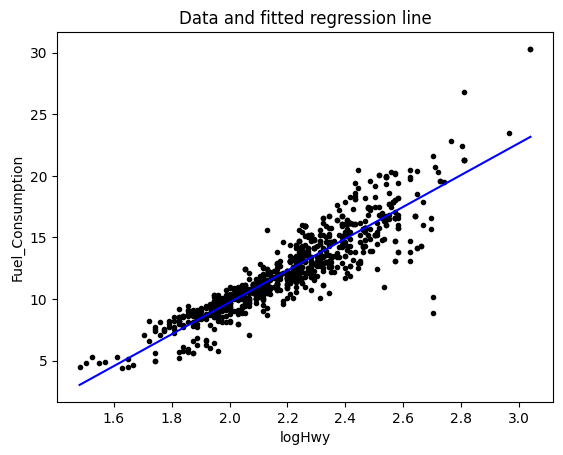

In [21]:
predictor = "logHwy"
outcome = "Fuel_Consumption"
data = car.copy()
results_ = results_fuel_log.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], color = "k", marker=".")

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)

fitted_values = a_hat + b_hat * x_domain

# Plot the fitted line
plt.plot(x_domain, fitted_values, label="Fitted line", color = "b")

# Add a legend and labels
# plt.legend()
plt.ylabel(outcome)
plt.xlabel(predictor)

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

### Model Comparison Summary

In [22]:
summary = pd.DataFrame({
    'Model': ['Linear (raw Hwy)', 'Log Transform (logHwy)', 'Reciprocal Transform (rec_Hwy)'],
    'R²': [results_model_car.rsquared, results_logtransform.rsquared, results_rectransform.rsquared],
    'R² (%)': [results_model_car.rsquared*100, results_logtransform.rsquared*100, results_rectransform.rsquared*100]
})
print(summary.to_string(index=False))

                         Model       R²    R² (%)
              Linear (raw Hwy) 0.807856 80.785628
        Log Transform (logHwy) 0.811804 81.180374
Reciprocal Transform (rec_Hwy) 0.773353 77.335341


- **Conclusion:** Based on the comparison of the three models, the **Log Transform model** using $\log(Hwy)$ achieves the highest $R^2$ value of **0.8118 (81.18%)**, making it the best-fitting model among the three for predicting combined fuel consumption from highway fuel consumption.

- Because we are transforming the `Hwy` variable using a log function, the interpretation of the regression coefficient changes — a one-unit increase in $\log(Hwy)$ corresponds to a percentage-based change in `Hwy`. The full interpretation in log terms will be discussed in the next project.

- **Recommendation:** Although the current model already has high explanatory power, further analysis can still consider adding other predictors (e.g., engine size, vehicle class, or transmission type) to explore whether the $R^2$ value can be increased and to build a more comprehensive combined fuel consumption model.
